# Differentiable Illumination Optimization

**NSQ as a differentiable machine-learning layer.**

When Optiland's backend is set to `"torch"` the non-sequential tracer builds
a full PyTorch autograd graph through the Monte Carlo loop.  Any scene
parameter stored as a `torch.Tensor` leaf variable — radius of curvature,
source flux, BSDF reflectance — receives a gradient via `loss.backward()`.

This notebook walks through a complete differentiable optimization example:

1. **Scene setup** — collimated source → singlet lens → irradiance detector
2. **Forward trace** — visualize the baseline irradiance map
3. **Optimization loop** — use `torch.optim.Adam` to drive the lens front
   radius `r1` toward a flat (uniform) irradiance target
4. **Results** — loss curve and final irradiance map
5. **v1 limitations** — what gradients are and are not available today

---

> **Beta notice:** `optiland.nonsequential` is in beta.  The differentiable
> workflow shown here is fully supported; visibility gradients (silhouette /
> vignetting discontinuities) are zero in v1.  See the roadmap in the
> package docstring (`help(optiland.nonsequential)`) for planned improvements.

## 0. Imports and backend selection

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim

import optiland.backend as be
from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    CollimatedSourceConfig,
    IrradianceDetectorConfig,
    LensConfig,
    NSQScene,
    Spectrum,
)
from optiland.nonsequential.backends.torch_backend import TorchBackend

# Switch to the PyTorch backend -- this is required for autograd.
# All optiland.backend operations now use torch under the hood.
be.set_backend("torch")
# Use float64 for gradient stability. The differentiable Monte Carlo trace is
# numerically delicate near surface edges; float64 keeps gradients well-behaved
# at the CPU-runnable ray counts used here.
be.set_precision("float64")

print(f"Backend : {be.get_backend()}")
print(f"Device  : {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")


Backend : torch
Device  : cpu


## 1. Scene setup

We build a simple on-axis system:

```
Collimated source  →  N-BK7 singlet  →  Irradiance detector
    z = 0              z = 100 mm           z = 210 mm
```

The singlet has a plano-convex shape (`r1 = 120 mm`, `r2 = inf`) and a
10 mm semi-aperture.  At `z = 210 mm` the beam is still converging, so the
irradiance map shows a bright central peak — far from uniform.

The detector is 20 × 20 mm with 32 × 32 pixels — small enough to keep
memory low during the optimization loop.

In [2]:
NUM_PIXELS = 32          # detector resolution (NxN)
DETECTOR_SIZE = 20.0     # mm
SEED = 42


def build_scene(
    r1_value: float | torch.Tensor,
    num_rays: int = 2_000,
) -> NSQScene:
    """Return an NSQScene with a singlet whose front radius is r1_value.

    r1_value may be a plain float (forward-only) or a torch.Tensor with
    requires_grad=True (differentiable).
    """
    spec = Spectrum.monochromatic(0.55)   # 550 nm green

    scene = NSQScene()

    # Collimated beam: 10 mm aperture radius, 1 W total flux
    scene.add_source(
        "S1",
        CoordinateSystem(z=0.0),
        CollimatedSourceConfig(
            spectrum=spec,
            total_flux=1.0,
            aperture_radius=10.0,
        ),
    )

    # Singlet lens: initial r1 = 120 mm, back flat, 5 mm thick N-BK7
    scene.add_lens(
        "L1",
        CoordinateSystem(z=100.0),
        LensConfig(
            r1=r1_value,       # float, or a requires_grad tensor
            r2=float("inf"),   # flat back surface
            thickness=5.0,
            material="N-BK7",
            front_aperture_radius=10.0,
        ),
    )

    # Irradiance detector: 20x20 mm, 32x32 pixels, bilinear splat
    scene.add_detector(
        "D1",
        CoordinateSystem(z=210.0),
        IrradianceDetectorConfig(
            width=DETECTOR_SIZE,
            height=DETECTOR_SIZE,
            num_pixels_x=NUM_PIXELS,
            num_pixels_y=NUM_PIXELS,
            splat="bilinear",   # differentiable splatting
        ),
    )

    return scene


print("Scene factory defined.")

Scene factory defined.


## 2. Forward trace — baseline irradiance map

Before optimizing, let's see what the irradiance pattern looks like with
the initial radius `r1 = 120 mm`.  We use a larger ray count here for a
clean visualization.

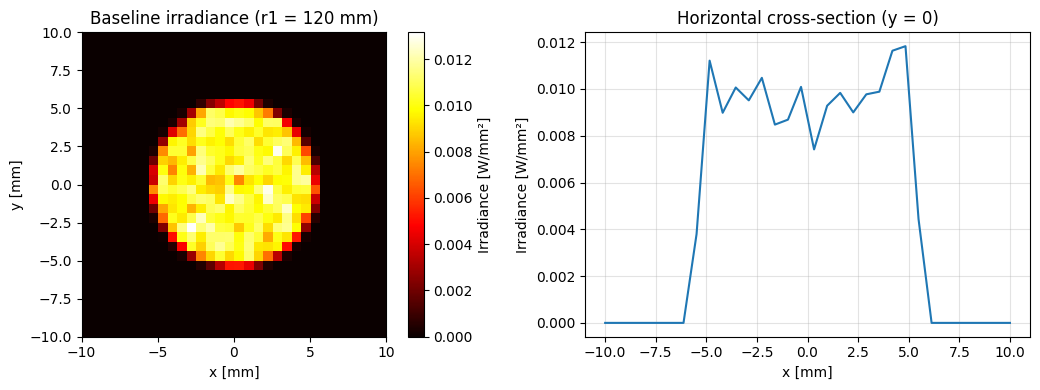

Peak irradiance : 0.0132 W/mm²
Mean irradiance : 0.0023 W/mm²
Uniformity ratio: 0.174  (1.0 = perfect flat top)


In [3]:
with torch.no_grad():
    scene_init = build_scene(r1_value=120.0, num_rays=10_000)
    backend_init = TorchBackend(seed=SEED)
    result_init = backend_init.trace(scene_init, num_rays=10_000, max_depth=8)

irr_init = result_init.detectors["D1"].irradiance   # (ny, nx) numpy array

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].imshow(
    irr_init, origin="lower",
    extent=[-DETECTOR_SIZE/2, DETECTOR_SIZE/2,
            -DETECTOR_SIZE/2, DETECTOR_SIZE/2],
    cmap="hot",
)
axes[0].set_title("Baseline irradiance (r1 = 120 mm)")
axes[0].set_xlabel("x [mm]")
axes[0].set_ylabel("y [mm]")
plt.colorbar(im, ax=axes[0], label="Irradiance [W/mm²]")

# Cross-section
cy = NUM_PIXELS // 2
axes[1].plot(np.linspace(-DETECTOR_SIZE/2, DETECTOR_SIZE/2, NUM_PIXELS),
             irr_init[cy, :], lw=1.5)
axes[1].set_xlabel("x [mm]")
axes[1].set_ylabel("Irradiance [W/mm²]")
axes[1].set_title("Horizontal cross-section (y = 0)")
axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

print(f"Peak irradiance : {irr_init.max():.4f} W/mm²")
print(f"Mean irradiance : {irr_init.mean():.4f} W/mm²")
print(f"Uniformity ratio: {irr_init.mean()/irr_init.max():.3f}  (1.0 = perfect flat top)")

## 3. Optimization loop

**Objective:** minimize the mean-squared error (MSE) between the irradiance
map and a flat (uniform) target.

**Design variable:** the front radius of curvature `r1` of the singlet.

**Gradient path:** `r1` (a `torch.Tensor` leaf) → `ConicGeometry._sag()` →
`ray_intersect()` → refracted direction → splat weight → `IrradianceMap.data`
→ `loss.backward()` → `r1.grad`.

---

### Ray count note

We use **2 000 rays** per step.  This keeps each forward pass fast and keeps
memory within the v1 gradient-mode envelope (~1 × 10⁵ rays × depth 16 on a
single GPU).  Monte Carlo noise at 2 000 rays is noticeable — increase to
10 000–50 000 rays for production runs, at proportionally higher memory cost.
Common-random-numbers (fixed seed) reduce variance further.

### What `loss.backward()` does

PyTorch walks the autograd graph from `loss` back to `r1`, accumulating
`∂loss/∂r1`.  `optimizer.step()` then nudges `r1` in the gradient-descent
direction.  No hand-written Jacobians are needed.

<div class="alert alert-warning">

**⚠ Visibility gradients are zero (v1).** This loop optimizes `r1` through the **interior** refraction path, which is fully differentiable. But if `r1` changes enough that rays begin to **vignette** at an aperture edge, that silhouette boundary contributes **no gradient** — the single biggest physics gap in the beta. Keep design moves within the unvignetted regime, or expect the optimizer to ignore edge effects. See the canonical [NSQ Limitations &amp; Roadmap](limitations_and_roadmap.html) page (roadmap item #1: reparameterization).

</div>

In [4]:
NUM_RAYS_OPT  = 2_000    # rays per optimization step
NUM_STEPS     = 60       # Adam steps
LEARNING_RATE = 5.0      # mm / step  (large because radius is in mm)
OPT_SEED      = 7        # fixed seed -> common random numbers

# IrradianceMap.data is the attached flat (ny*nx,) flux buffer. Dividing the
# reshaped grid by the pixel area gives a differentiable irradiance [W/mm^2],
# matching the units of irr_init used to build the target.
PIXEL_AREA = (DETECTOR_SIZE / NUM_PIXELS) ** 2

# ---- design variable -------------------------------------------------------
r1 = torch.tensor(120.0, requires_grad=True, dtype=torch.float64)
optimizer = optim.Adam([r1], lr=LEARNING_RATE)

# ---- flat target irradiance (uniform, same mean) --------------------------
target_value = float(irr_init.mean())   # W/mm^2
target = torch.full(
    (NUM_PIXELS, NUM_PIXELS), target_value, dtype=torch.float64
)

print(f"Target irradiance (flat): {target_value:.5f} W/mm^2")
print(f"Starting r1             : {r1.item():.2f} mm")
print(f"Optimizing for {NUM_STEPS} steps ...")

# ---- optimization loop -----------------------------------------------------
loss_history = []
r1_history   = []

for step in range(NUM_STEPS):
    optimizer.zero_grad()

    # Rebuild the scene each step so the tensor r1 is wired into fresh geometry.
    # This is the standard pattern for NSQ differentiable optimization.
    scene = build_scene(r1_value=r1, num_rays=NUM_RAYS_OPT)
    backend = TorchBackend(seed=OPT_SEED)   # same seed -> low-variance gradient
    result = backend.trace(scene, num_rays=NUM_RAYS_OPT, max_depth=8)

    # Differentiable irradiance map [W/mm^2] (grad_fn attached)
    irr_tensor = (
        result.detectors["D1"].data.reshape(NUM_PIXELS, NUM_PIXELS) / PIXEL_AREA
    )

    # MSE vs. flat target
    loss = torch.mean((irr_tensor - target) ** 2)

    # Backpropagate through the entire Monte Carlo trace
    loss.backward()

    # Clip gradient to stabilise early steps
    torch.nn.utils.clip_grad_norm_([r1], max_norm=50.0)

    optimizer.step()

    # Clamp to a physically sensible range (avoid near-zero or negative radius)
    with torch.no_grad():
        r1.clamp_(min=30.0, max=600.0)

    loss_history.append(loss.item())
    r1_history.append(r1.item())

    if (step + 1) % 10 == 0:
        print(
            f"Step {step+1:3d}/{NUM_STEPS}  "
            f"loss={loss.item():.2e}  "
            f"r1={r1.item():.2f} mm  "
            f"grad={r1.grad.item():.3e}"
        )

print(f"\nFinal r1 = {r1.item():.2f} mm  (started at 120.00 mm)")


Target irradiance (flat): 0.00229 W/mm^2
Starting r1             : 120.00 mm
Optimizing for 60 steps ...


Step  10/60  loss=1.11e-05  r1=164.21 mm  grad=-1.017e-07


Step  20/60  loss=8.63e-06  r1=197.42 mm  grad=-5.501e-08


Step  30/60  loss=7.53e-06  r1=222.01 mm  grad=-3.553e-08


Step  40/60  loss=6.95e-06  r1=240.50 mm  grad=-2.849e-08


Step  50/60  loss=6.55e-06  r1=255.64 mm  grad=-2.337e-08


Step  60/60  loss=6.27e-06  r1=268.63 mm  grad=-1.989e-08

Final r1 = 268.63 mm  (started at 120.00 mm)


## 4. Results — loss curve and final irradiance map

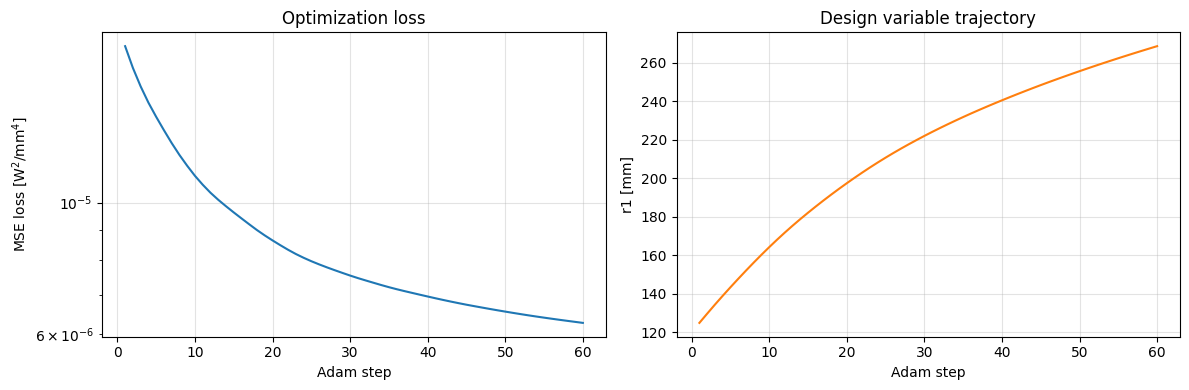

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---- loss curve ----
ax = axes[0]
ax.semilogy(range(1, NUM_STEPS + 1), loss_history, lw=1.5, color="tab:blue")
ax.set_xlabel("Adam step")
ax.set_ylabel("MSE loss [W$^2$/mm$^4$]")
ax.set_title("Optimization loss")
ax.grid(True, alpha=0.35)

# ---- r1 trajectory ----
ax = axes[1]
ax.plot(range(1, NUM_STEPS + 1), r1_history, lw=1.5, color="tab:orange")
ax.set_xlabel("Adam step")
ax.set_ylabel("r1 [mm]")
ax.set_title("Design variable trajectory")
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()


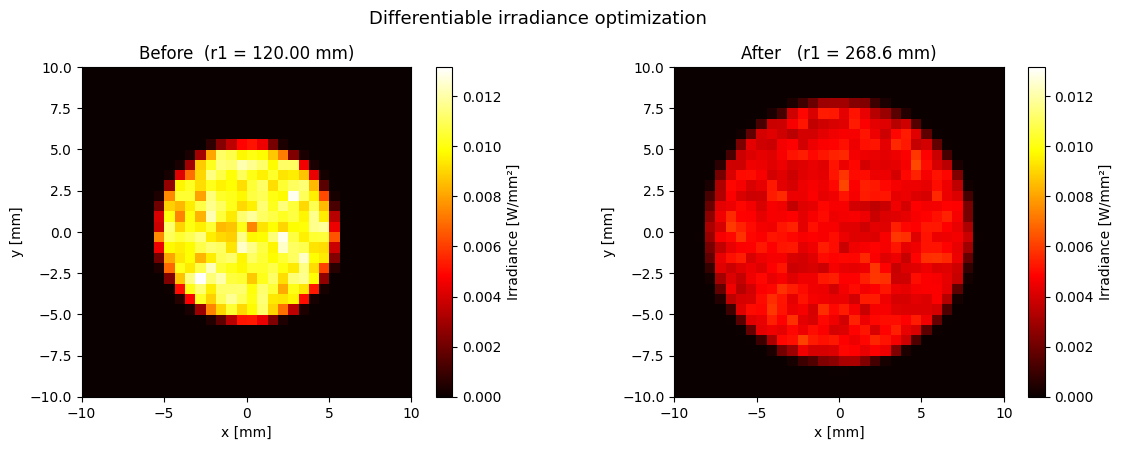

Uniformity ratio before : 0.174
Uniformity ratio after  : 0.366
(1.0 = perfectly flat top)


In [6]:
# ---- final irradiance map (higher ray count for cleaner visualization) ----
with torch.no_grad():
    scene_final = build_scene(r1_value=r1.item(), num_rays=20_000)
    backend_final = TorchBackend(seed=SEED)
    result_final = backend_final.trace(scene_final, num_rays=20_000, max_depth=8)

irr_final = result_final.detectors["D1"].irradiance

# Use a shared colour scale so both maps are directly comparable
vmax = max(irr_init.max(), irr_final.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
extent = [-DETECTOR_SIZE/2, DETECTOR_SIZE/2,
          -DETECTOR_SIZE/2, DETECTOR_SIZE/2]

for ax, irr, title in zip(
    axes,
    [irr_init, irr_final],
    [f"Before  (r1 = 120.00 mm)",
     f"After   (r1 = {r1.item():.1f} mm)"],
):
    im = ax.imshow(irr, origin="lower", extent=extent,
                   cmap="hot", vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
    plt.colorbar(im, ax=ax, label="Irradiance [W/mm²]")

plt.suptitle("Differentiable irradiance optimization", fontsize=13)
plt.tight_layout()
plt.show()

uniformity_before = irr_init.mean() / (irr_init.max() + 1e-12)
uniformity_after  = irr_final.mean() / (irr_final.max() + 1e-12)
print(f"Uniformity ratio before : {uniformity_before:.3f}")
print(f"Uniformity ratio after  : {uniformity_after:.3f}")
print(f"(1.0 = perfectly flat top)")

## 5. v1 limitations and how to work around them

### What works

Pass a `torch.tensor(..., requires_grad=True)` straight into the ordinary
config object — no private attributes, no post-construction patching.

| Parameter | How |
|---|---|
| Lens radius (`r1`, `r2`) and conic (`conic1`, `conic2`) | `LensConfig(r1=r1_tensor, ...)` |
| Component aperture radius | `LensConfig(front_aperture_radius=...)`, `MirrorConfig(aperture_radius=...)` |
| Mirror radius | `MirrorConfig(radius=...)` |
| Source `total_flux` | `CollimatedSourceConfig(total_flux=...)` |
| BSDF reflectance | `LambertianBSDF(reflectance=...)` |
| Material refractive index | `NSQMaterial` index |
| Irradiance detector `width` / `height` | `IrradianceDetectorConfig(width=..., height=...)` |

Detector pixel *counts* are integers and structural, so they are not
differentiable.

Parameters that cannot carry gradients in v1 **raise `NotImplementedError`**
rather than detaching silently — a design variable that has no effect on the
loss should fail loudly, not sit at zero gradient. This applies to source
geometry (`aperture_radius`, `half_angle_deg`, extended-source extent), whose
sampling runs in NumPy, and to `SpectralDetector` extents.

### What does NOT work in v1

1. **Visibility gradients are zero.**  When `r1` is changed enough that
   rays start to vignette at the aperture edge, the gradient through that
   boundary is zero.  The optimizer can still make progress through the
   interior (refraction) path, but the silhouette contribution is missing.
   *Roadmap item #1 — reparameterization — will fix this.*

2. **Mesh geometry is forward-only.**  `MeshGeometry.ray_intersect()` uses
   a numpy BVH; calling `loss.backward()` through it will raise.  Use
   `ConicGeometry` / `SphereGeometry` / `ParaboloidGeometry` for
   differentiable surfaces.

3. **Memory cap at ~1 × 10⁵ rays.**  The fixed-depth autograd graph stores
   O(num_rays × max_depth) activations.  At 2 000 rays and depth 8 the
   footprint is negligible; at 1 × 10⁵ rays and depth 16 you will need
   ~8 GB of GPU VRAM.  *Roadmap item #3 — Path Replay Backpropagation —
   reduces this to O(num_rays).*

4. **No polarization.**  Stokes tracking is roadmap item #6.

### Tips for stable optimization

- **Common-random-numbers (fixed seed):** re-using the same RNG seed across
  steps keeps gradient variance low (as done above with `OPT_SEED = 7`).
- **Gradient clipping:** `clip_grad_norm_` prevents large steps early in
  training when the gradient is noisy.
- **Warm start:** run 5–10 forward-only passes first to verify the scene
  produces rays on the detector before enabling autograd.
- **Detach for diagnostics:** wrap visualization/metrics in
  `with torch.no_grad():` to avoid building unnecessary graph nodes.

## Summary

The minimum differentiable NSQ loop is:

```python
import optiland.backend as be
import torch, torch.optim as optim
from optiland.nonsequential.backends.torch_backend import TorchBackend

be.set_backend("torch")
be.set_precision("float64")   # recommended for gradient work

r1 = torch.tensor(120.0, requires_grad=True, dtype=torch.float64)
optimizer = optim.Adam([r1], lr=5.0)

for step in range(100):
    optimizer.zero_grad()
    scene = build_scene(r1)           # LensConfig(r1=r1) - tensor goes straight in
    result = TorchBackend(seed=42).trace(scene, num_rays=2_000)
    loss = my_loss(result.detectors["D1"].data)
    loss.backward()                   # gradient through full MC trace
    optimizer.step()
```

---

**Feedback and contributions welcome.**  If you use this workflow for a real
illumination or stray-light problem, open a GitHub issue and describe your
use case — feedback directly shapes the roadmap:
https://github.com/HarrisonKramer/optiland/issues